In [28]:
import numpy as np
import pandas as pd
from tqdm import trange
import utm
import time
import os
import pickle as pkl
import inspect

from obspy import read

from obspy.clients.fdsn import Client

# import UTCDateTime from obspy
from obspy.core.utcdatetime import UTCDateTime as UTC
from obspy.core.event.catalog import read_events
import datetime
import matplotlib.pyplot as plt

from haversine import haversine, Unit
import math

from seismo_functions import load_tt

In [519]:
cat_dir = "/Users/ivandevert/projects/ridgecrest2019/data/catalogs/"
eloc_catalog_path = "/Users/ivandevert/projects/ridgecrest2019/data/trugman_ridgecrest2019_relocated_catalog.txt"
datetime_precision = 'ns'

tbuf = -0.15
twin = 1.5
Fs_resample = 100


plot_example_spectra = True
plot_example_percentage = 0.001
figure_save_dir = "/Users/ivandevert/projects/ridgecrest2019/figures/example_spectra/"
spectra_save_dir = "/Users/ivandevert/projects/ridgecrest2019/spectra/"

In [432]:
nwin = int(twin * Fs_resample)
nf = int(nwin / 2 + 1)
fN = Fs_resample / 2


In [188]:
class MiniseedReader:
    def __init__(self, seismogram_paths):
        self.seismogram_paths = seismogram_paths

def obspy_catalog_to_df(catalog, client_format='SCEDC'):

    event_name = []
    station_name = []
    pick_phase = []
    pick_time = []
    


    for i in trange(len(catalog)):
        ev = catalog[i]
        ename = int(ev.resource_id.id.split('=')[-1])

        picks = ev.picks
        sname = [[]] * len(picks)
        pphase = [[]] * len(picks)
        ptime = [[]] * len(picks)
        for p, pick in enumerate(picks):
            sname[p] = pick.waveform_id.id
            pphase[p] = pick.phase_hint
            ptime[p] = (np.datetime64(pick.time.datetime, 'ms') - np.datetime64(ev.origins[0].time, 'ms')).astype(float) * 1E-3
        event_name += [ename] * len(picks)
        station_name += sname
        pick_phase += pphase
        pick_time += ptime

    df = pd.DataFrame(
        {
            'event_name':       event_name,
            'station_name':     station_name,
            'pick_phase':       pick_phase,
            'pick_time':        pick_time
        }
    )
    
    # sort by event_name
    df = df.sort_values(by='event_name').reset_index(drop=True)

    return df

# compute distances between events and stations in km
def geo_distance(lat1, lon1, lat2, lon2):
    earth_radius = 6371.0
    # Convert all angles to radians
    lat1_r = np.deg2rad(lat1)
    lon1_r = np.deg2rad(lon1)
    lat2_r = np.deg2rad(lat2)
    lon2_r = np.deg2rad(lon2)
    # Calculate the distance
    dp = np.cos(lat1_r) * np.cos(lat2_r) * np.cos(lon1_r - lon2_r) + np.sin(lat1_r) * np.sin(lat2_r)
    angle = np.arccos(dp)
    return earth_radius * angle

# df_picks = obspy_catalog_to_df(cat1)
# with open(f"{cat_dir}picks_scedc.pkl", 'wb') as fs:
#     pkl.dump(df_picks, fs)


In [32]:
# each of these dirs contains folders, one per event, containing seismograms, one per station
dirs_containing_events = [
    "/Volumes/ianhdd/LaCie/ridgecrest_data/RC_M2.0to2.5/",
    "/Volumes/ianhdd/LaCie/ridgecrest_data/RC_M3above/"
]

# earthquake location catalog (Trugman 2020)
eloc_catalog_path = "/Users/ivandevert/projects/ridgecrest2019/data/trugman_ridgecrest2019_relocated_catalog.txt"

p_traveltime_path = "/Users/ivandevert/projects/ridgecrest2019/data/out.ttP"
s_traveltime_path = "/Users/ivandevert/projects/ridgecrest2019/data/out.ttS"

X, Y, ttp = load_tt(p_traveltime_path)
X, Y, tts = load_tt(s_traveltime_path)


In [5]:
# First, get all the dirs of the events
event_dirs = []
for d in dirs_containing_events:
    event_dirs += [os.path.join(d,f)+"/" for f in os.listdir(d) if os.path.isdir(os.path.join(d,f))]
# event_names = [event_dirs[i].split('/')[-1] for i in range(len(event_dirs))]

# Get all paths of seismograms
seismogram_paths = []
for i in trange(len(event_dirs)):
    d = event_dirs[i]
    seismogram_paths += [os.path.join(d,f) for f in os.listdir(d) if f.endswith('.ms')]


100%|██████████| 1542/1542 [00:07<00:00, 197.54it/s] 


In [6]:
event_names, record_names = np.array(
    [fp.split('/')[-2:] for fp in seismogram_paths]
    ).T
sta, net, cha, loc, syr, jday, hms, event_name, ms = np.array(
    [record_names[i].split('.') for i in range(len(record_names))]
    ).T

event_names = np.array(event_names, dtype=int)
station_names = np.array(
    ['.'.join([net[i], sta[i], loc[i], cha[i]]) for i in range(len(sta))]
    )


In [9]:
# st = read(event_dirs[0]+"*.ms")
# st_cat = read_events(event_dirs[0]+"*.xml")

In [10]:


# begin process

ev_dep = []
st_dep = []
rec_dep = []

client_iris = Client('IRIS')
client_scedc = Client('SCEDC')
client_ncedc = Client('NCEDC')

df_files = pd.DataFrame(
    {
        'event_name':       event_names,
        'station_name':     station_names
    }
)
ev_dep += ['event_name']
st_dep += ['station_name']

df_files_ev = df_files.groupby(ev_dep, as_index=False)[st_dep].agg(list)
# df_st = df_files.groupby(st_dep, as_index=False)[ev_dep].agg(list)


In [189]:
starttime = '2019-07-03T00:00:00.000000Z'
endtime = '2019-07-19T00:00:00.000000Z'
# endtime = '2019-07-01T01:00:00.000000Z'
minmagnitude = 0.95
maxmagnitude = 9.0
minlongitude = -118.0
maxlongitude = -117.0
minlatitude = 35.0
maxlatitude = 37.0

bulk_dt_hours = 6

# split into days
t0_utc = UTC(starttime)
t1_utc = UTC(endtime)
iters = int(np.ceil((t1_utc - t0_utc) / (3600*bulk_dt_hours)))

clients = ["SCEDC", "IRIS"]

# check if catalog already exists
download_catalog = False
for cname in clients:
    if not os.path.exists(f"{cat_dir}picks_{cname.lower()}.pkl"):
        download_catalog = True
        print("will download catalog")

if download_catalog:
    for cname in clients:
        print(f"Downloading data from client {cname}...")
        client = Client(cname)
        cat = None
        for i in trange(int(iters)):
            t0 = t0_utc + i*3600*bulk_dt_hours
            t1 = t0_utc + (i+1)*3600*bulk_dt_hours
            try:
                cat_part = client.get_events(
                    starttime=str(t0),
                    endtime=str(t1),
                    minmagnitude=minmagnitude,
                    maxmagnitude=maxmagnitude,
                    minlongitude=minlongitude,
                    maxlongitude=maxlongitude,
                    minlatitude=minlatitude,
                    maxlatitude=maxlatitude,
                    includearrivals=True
                    )
                if cat:
                    cat += cat_part
                else:
                    cat = cat_part
            except Exception as e:

                # no data error (no events in timeframe)
                if e.status_code==204:
                    pass
                else:
                    print(e)

        # takes sooooo long
        # cat.write(cat_dir + f'catalog_{cname.lower()}.xml', format='quakeml')

        df_picks = obspy_catalog_to_df(cat)
        with open(f"{cat_dir}picks_{cname.lower()}.pkl", 'wb') as fs:
            pkl.dump(df_picks, fs)

df_picks = None

for cname in clients:
    with open(f"{cat_dir}picks_{cname.lower()}.pkl", 'rb') as fs:
        if df_picks is not None:
            df_picks = pd.concat([df_picks, pkl.load(fs)])
        else:
            df_picks = pkl.load(fs)
df_picks = df_picks.reset_index(drop=True)
df_picks['event_name'] = df_picks['event_name'].astype(int)
df_picks['sloc'] = ['.'.join(el.split('.')[:-1]) for el in df_picks['station_name'].values]
# this might have multiple entries for the same record/phase combo

will download catalog
will download catalog


  0%|          | 0/64 [00:00<?, ?it/s]

100%|██████████| 18540/18540 [00:43<00:00, 428.93it/s]


100%|██████████| 15046/15046 [00:00<00:00, 382634.33it/s]


In [193]:
# download station information, or load from file

download_stations = False
if not os.path.exists(f"{cat_dir}inv_ridgecrest.pkl"):
    download_stations = True
    print("will download station information")
    raise NotImplementedError("not written yet")
else:
    with open(f"{cat_dir}inv_ridgecrest.pkl", 'rb') as fs:
        df_stations = pkl.load(fs)
df_stations['sloc'] = ['.'.join(el.split('.')[:-1]) for el in df_stations['station_name'].values]

In [196]:

# Load Trugman (2020) earthquake relocations
df_locations = pd.read_csv(
    eloc_catalog_path,
    sep=r'\s+',
    skiprows=28,
    header=None,
    names=[
        'event_name', 'ymd', 'hms', 'emag', 'elon', 'elat', 'edep', 'relocated'
        ],
    dtype={
        'event_name': int,
        'ymd': str,
        'hms': str,
        'emag': float,
        'elon': float,
        'elat': float,
        'edep': float,
        'relocated': bool,
        }
)
df_locations['etime'] = df_locations['ymd'] + 'T' + df_locations['hms'] + "Z"
df_locations['etime'] = [UTC(el).datetime for el in df_locations['etime'].values]
df_locations.drop(columns=['ymd', 'hms'], inplace=True)
# sort by event_name
df_locations = df_locations.sort_values(by='event_name').reset_index(drop=True)

In [228]:
def merge_picks(df, df_picks):

    DF = df.copy()
    DF['sloc'] = ['.'.join(el.split('.')[:-1]) for el in DF['station_name'].values]

    print("Matching picks to event and station pairs...", end='')
    # Separate P and S picks
    df_p = df_picks.copy()
    df_s = df_picks.copy()

    # drop rows with 'S' pick_phase from df_p
    df_p = df_p[df_p['pick_phase'] == 'P'].reset_index(drop=True)
    df_s = df_s[df_s['pick_phase'] == 'S'].reset_index(drop=True)

    # rename pick_time to pick_p or pick_s
    df_p.rename(columns={'pick_time': 'p_arrival'}, inplace=True)
    df_s.rename(columns={'pick_time': 's_arrival'}, inplace=True)

    # drop pick_phase
    df_p.drop(columns=['pick_phase'], inplace=True)
    df_s.drop(columns=['pick_phase'], inplace=True)

    # apply picks to location, not just channel
    df_p = df_p.groupby(['event_name', 'sloc'], as_index=False)[['p_arrival']].agg(list)
    df_s = df_s.groupby(['event_name', 'sloc'], as_index=False)[['s_arrival']].agg(list)
    df_p['p_arrival'] = df_p['p_arrival'].apply(np.nanmean)
    df_s['s_arrival'] = df_s['s_arrival'].apply(np.nanmean)

    # merge both into df
    df_out = pd.merge(DF, df_p, how='left', on=['event_name', 'sloc'])
    df_out = pd.merge(df_out, df_s, how='left', on=['event_name', 'sloc'])

    # drop sloc column
    df_out.drop(columns=['sloc'], inplace=True)

    # fill NaN with -99.0 in p_arrival and s_arrival
    df_out.fillna(-99.0, inplace=True)

    print("Done.")
    return df_out

In [234]:
# Now, I have four dataframes:
# 1) df_files: all downloaded seismograms (event_name, station_name)
# 2) df_picks: all cataloged picks (event_name, station_name, pick_phase, pick_time)
# 3) df_locations: all event locations (event_name, emag, elon, elat, edep, etime)
# 4) df_stations: all station information (station_name, slat, slon, sele, local_depth, sample_rate, sdip, sazi)
#
# 
df = df_files.copy()
ev_dep = ['event_name']
st_dep = ['station_name']
rec_dep = []
loc_dep = []
cha_dep = []
print(f"Number of seismograms loaded: {len(df):,}")

# Merge picks into df
df = merge_picks(df, df_picks)
rec_dep += ['p_arrival', 's_arrival']
print(f"Number of seismograms with P picks: {len(df[df['p_arrival']!=-99.0]):,} ({len(df[df['p_arrival']!=-99.0])/len(df)*100:.2f}%)")
print(f"Number of seismograms with S picks: {len(df[df['s_arrival']!=-99.0]):,} ({len(df[df['s_arrival']!=-99.0])/len(df)*100:.2f}%)")

# Add magnitude, event location, and origin times to df
print("Adding event magnitude, location, and origin times...", end='')
df_ev = df.groupby(ev_dep, as_index=False)[st_dep+rec_dep].agg(list)
df_ev = pd.merge(df_ev, df_locations, how='left', on=ev_dep)
ev_dep += ['emag', 'elon', 'elat', 'edep', 'relocated', 'etime']
df = df_ev.explode(st_dep+rec_dep).reset_index(drop=True)
print("Done.")
print(f"Number of events loaded from Trugman (2020): {len(df_locations):,}")

# Merge station information into df
print("Adding station location and information...", end='')
df_st = df.groupby(st_dep, as_index=False)[ev_dep+rec_dep].agg(list)
df_st = pd.merge(df_st, df_stations, how='left', on=st_dep)
st_dep += ['slat', 'slon', 'sele', 'local_depth', 'sample_rate', 'sdip', 'sazi']
df = df_st.explode(ev_dep+rec_dep).reset_index(drop=True)
print("Done.")
print(f"Number of stations/channels loaded from downloaded inventory: {len(df_stations):,}")
print(f"Number of stations/channels used: {len(df_st):,}")

# Add station-event distance
df['rec_dist'] = geo_distance(
    df['elat'].values.astype(float), 
    df['elon'].values.astype(float), 
    df['slat'].values.astype(float), 
    df['slon'].values.astype(float)
)
rec_dep += ['rec_dist']

df_ev = df.groupby(ev_dep, as_index=False)[st_dep+rec_dep].agg(list)
df_st = df.groupby(st_dep, as_index=False)[ev_dep+rec_dep].agg(list)

# # want to group such that each row is an event/location pair
# loc_dep = st_dep.copy()
# cha_dep = ['station_name', 'sample_rate', 'sdip', 'sazi']

# for el in ['station_name', 'sample_rate', 'sdip', 'sazi']:
#     loc_dep.remove(el)

# df_loc = df.groupby(loc_dep, as_index=False)[ev_dep+rec_dep+cha_dep].agg(list)


Number of seismograms loaded: 371,279
Matching picks to event and station pairs...Done.
Number of seismograms with P picks: 209,201 (56.35%)
Number of seismograms with S picks: 177,988 (47.94%)
Adding event magnitude, location, and origin times...Done.
Number of events loaded from Trugman (2020): 12,943
Adding station location and information...Done.
Number of stations/channels loaded from downloaded inventory: 11,441
Number of stations/channels used: 476


In [235]:
# assign approximate p and s arrival times based on travel time tables

def get_pick_estimate(X, Y, TT, distance, depth):
    """Get an estimated pick time for a given event-station distance 
    and event depth using a travel time table.

    This is designed to interpolate travel times from Peter's traveltime
    codes. X, Y, and TT are np.ndarray objects output from the load_tt()
    function in stressdrop_file_IO.py. See interpolate_grid() for more 
    detailed information.

    Args:
        X (np.ndarray): Distance spacing array
        Y (np.ndarray): Depth spacing array
        TT (np.ndarray): Estimated travel times for given X and Y points
        distance (float): Event-station distance (km or degrees)
        depth (float): Event depth (km)

    Returns:
        Tinterp (float): Estimated travel time

    Sources:

    Last Modified:
        2024-02-06
    """

    dx = X[1] - X[0]
    dy = Y[1] - Y[0]
    
    try:
        # get indices of the element to the left of the value in the X and Y
        # directions. Ex: for X = [0, 1, 2, 3] and distance = 1.12, ix = 1
        ix = np.abs(X - distance).argmin()
        iy = np.abs(Y - depth).argmin()
        if distance < (ix * dx): ix -= 1
        if depth <= (iy * dy): iy -= 1

        # get left and right element relative to actual value
        xx = X[ix:ix+2]
        yy = Y[iy:iy+2]
        
        # get 4 elements surrounding actual value
        tt = TT[ix:ix+2,iy:iy+2]

        # notation: T0p: T at x[0], Yp or T(x[0], Yp)
        # Tij = T(xi, yj)
        T0p = ((tt[0,1]-tt[0,0]) / dy ) * (depth - yy[0]) + tt[0,0] #top
        T1p = ((tt[1,1]-tt[1,0]) / dy ) * (depth - yy[0]) + tt[1,0] #bottom
        Tp0 = ((tt[1,0]-tt[0,0]) / dx ) * (distance - xx[0]) + tt[0,0] #left
        Tp1 = ((tt[1,1]-tt[0,1]) / dx ) * (distance - xx[0]) + tt[0,1] #right

        # interpolate along midlines
        Tpx = ((T1p - T0p)/ dx ) * (distance - xx[0]) + T0p
        Tpy = ((Tp1 - Tp0)/ dy ) * (depth - yy[0]) + Tp0
        
        Tinterp = (Tpx+Tpy)/2
    except Exception as E:
        print(E)
        print(f"depth: {depth:.2f}")
        print(f"distance: {distance:.2f}")
        print(f"xx: {xx}")
        print(f"yy: {yy}")
        print(f"tt: {tt}")
        Tinterp = -99999.0
    return Tinterp



In [244]:
p_arrival_est = np.zeros(len(df))
s_arrival_est = np.zeros(len(df))

for i in range(len(df)):
    distance = df['rec_dist'].values[i]
    depth = df['edep'].values[i] + df['sele'].values[i]*0.001

    if depth < 0: depth = 0.0001
    p_arrival_est[i] = get_pick_estimate(X, Y, ttp, distance, depth)
    s_arrival_est[i] = get_pick_estimate(X, Y, tts, distance, depth)

df['p_arrival_est'] = p_arrival_est
df['s_arrival_est'] = s_arrival_est

In [270]:
# print out some stats:

# number of records with no picks
n_0_picks = df[(df['p_arrival']==-99.0) & (df['s_arrival']==-99.0)]
print(f"Number of records with no picks: {len(n_0_picks):,} ({len(n_0_picks)/len(df)*100:.2f}%)")

# number of records with only a p-pick:
n_p_picks = df[(df['p_arrival']!=-99.0) & (df['s_arrival']==-99.0)]
print(f"Number of records with only a p-pick: {len(n_p_picks):,} ({len(n_p_picks)/len(df)*100:.2f}%)")

# number of records with only a s-pick:
n_s_picks = df[(df['p_arrival']==-99.0) & (df['s_arrival']!=-99.0)]
print(f"Number of records with only a s-pick: {len(n_s_picks):,} ({len(n_s_picks)/len(df)*100:.2f}%)")

# number of records with either a p- or s-pick:
n_1_picks = df[(df['p_arrival']!=-99.0) | (df['s_arrival']!=-99.0)]
print(f"Number of records with either a p- or s-pick: {len(n_1_picks):,} ({len(n_1_picks)/len(df)*100:.2f}%)")

# number of records with both picks:
n_2_picks = df[(df['p_arrival']!=-99.0) & (df['s_arrival']!=-99.0)]
print(f"Number of records with both picks: {len(n_2_picks):,} ({len(n_2_picks)/len(df)*100:.2f}%)")

# total records
print(f"Total number of records: {len(df):,}")

Number of records with no picks: 139,494 (37.57%)
Number of records with only a p-pick: 53,797 (14.49%)
Number of records with only a s-pick: 22,584 (6.08%)
Number of records with either a p- or s-pick: 231,785 (62.43%)
Number of records with both picks: 155,404 (41.86%)
Total number of records: 371,279


Compute spectra

In [ ]:
from multitaper import mtspec
# Compute spectra
phase = 'P'
nw = 4
kspec = 0


c_trace = 'gray'
c_noise = 'r'
c_signal = 'k'
n_plot = int(len(seismogram_paths) * plot_example_percentage)
iplot = np.random.choice(len(seismogram_paths), n_plot, replace=False)

if phase.lower() == 'p':
    arrival = 'p_arrival'
    arrival_est = 'p_arrival_est'
elif phase.lower() == 's':
    arrival = 's_arrival'
    arrival_est = 's_arrival_est'

f_resample = np.linspace(0, fN, nf)

df_event_names = df['event_name'].values
df_station_names = df['station_name'].values

s1 = np.empty((len(df), nf), dtype=float)
s2 = np.empty((len(df), nf), dtype=float)

x1 = np.empty((len(df), nwin), dtype=float)
x2 = np.empty((len(df), nwin), dtype=float)

bad_records = []

n = 0
for i in trange(len(seismogram_paths)): 
    ev_id = event_names[i]
    st = read(seismogram_paths[i])
    assert len(st) == 1
    tr = st[0]
    st_id = tr.id
    npts = tr.stats.npts

    # maybe speed up by defining integer IDs for event_name and station_name?
    # find row index number in df that matches event_name, station_name
    df_row = df[np.logical_and(df_event_names == ev_id, df_station_names == st_id)]
    index = df_row.index[0]
    # # about 70 iterations/s

    # make sure only one row found (can delete later)
    assert len(df_row) == 1

    # Store the origin time as a numpy datetime64
    origin_dt = df_row['etime'].values[0]

    # Store the actual and estimated pick times
    t_pick_actual = df_row[arrival].values[0]
    t_est_pick = df_row[arrival_est].values[0]

    # Determine which pick to use
    if t_pick_actual == -99.0:
        t_pick = t_est_pick
    else:
        t_pick = t_pick_actual

    # Compute time between origin and starttime (positive if starttime before origin)
    tdif = (origin_dt - np.datetime64(tr.stats.starttime)).astype(float)*1E-9

    if tdif < 0:
        bad_records.append(index)
        continue

    # Detrend the entire seismogram
    tr.detrend('linear')

    # Time array, relative to origin time
    t = tr.times() - tdif

    # Determine first and last indices of signal window
    i0 = np.argmin(np.abs((t) - (t_pick + tbuf)))
    i1 = i0 + int(twin / tr.stats.delta)

    # Determine first and last indices of noise window, immediately preceding signal window
    in1 = i0
    in0 = in1 - int(twin / tr.stats.delta)

    # Extract signal and noise windows
    signal = tr.data[i0:i1]
    noise = tr.data[in0:in1]

    t_signal = t[i0:i1]
    t_noise = t[in0:in1]

    if (len(signal) * tr.stats.delta < twin) | (len(noise) * tr.stats.delta < twin):
        bad_records.append(index)
        continue

    f_signal, s_signal = mtspec.MTSpec(signal, nw=nw, kspec=kspec, dt=tr.stats.delta, nfft=int(2*(i1-i0))).rspec()
    f_noise, s_noise = mtspec.MTSpec(noise, nw=nw, kspec=kspec, dt=tr.stats.delta, nfft=int(2*(i1-i0))).rspec()

    # Interpolate noise and signal to desired frequency resolution
    if len(s_signal) != len(f_resample):
        s_signal = np.interp(f_resample, f_signal.flatten(), s_signal.flatten())
        s_noise = np.interp(f_resample, f_noise.flatten(), s_noise.flatten())
    
    assert len(s_signal) == len(f_resample)

    s1[index, :] = s_noise
    s2[index, :] = s_signal


    # Plot examples
    if plot_example_spectra:
        if i in iplot:
            fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
            ax1.axvline(x=0, c='k', lw=1, ls='--')

            if t_pick_actual != -99.0: ax1.axvline(x=t_pick_actual, c=c_signal, lw=1, label='Catalog pick')
            ax1.axvline(x=t_est_pick, c=c_signal, lw=1, ls=':', label='Estimated pick')

            ax1.plot(t, tr.data, c=c_trace, lw=0.5)
            ax1.plot(t_signal, signal, c=c_signal, lw=1, label='Signal')
            ax1.plot(t_noise, noise, c=c_noise, lw=1, label='Noise')

            xlim = [-1, t_pick + 10 + twin]
            ax1.set_xlim(xlim)
            fig.suptitle(f"{tr.id} | {ev_id} | M{df_row['emag'].values[0]:.2f} | {df_row['rec_dist'].values[0]:.2f} km | {tr.stats.sampling_rate:.2f} Hz")


            ax2.loglog(f_resample, s_signal, c=c_signal, lw=1, label='Signal')
            ax2.loglog(f_resample, s_noise, c=c_noise, lw=1, label='Noise')

            if tr.stats.sampling_rate < 101:
                ax2.set_xlim([0.1, 40])
            elif tr.stats.sampling_rate < 201:
                ax2.set_xlim([0.1, 80])


            ax1.legend()
            ax2.legend()
            ax1.set_xlabel('Time relative to origin (s)')
            ax1.set_ylabel('Amplitude')
            ax2.set_xlabel('Frequency (Hz)')
            ax2.set_ylabel('Spectral amplitude')
            ax2.set_xticks([0.1, 0.3, 1, 3, 10, 30])
            ax2.set_xticklabels([0.1, 0.3, 1, 3, 10, 30])

            plt.tight_layout()

            plt.savefig(f"{figure_save_dir}{ev_id}_{tr.id}.png")
            plt.close()
    
df['s1'] = list(s1)
df['s2'] = list(s2)

mask = np.ones(len(df), dtype=bool)
mask[bad_records] = False

df = df[mask].reset_index(drop=True)


  0%|          | 0/371279 [00:00<?, ?it/s]

100%|██████████| 371279/371279 [4:58:55<00:00, 20.70it/s]   


In [520]:
# save df in spectra_save_dir as pickle format
df.to_pickle(spectra_save_dir + 'spectra_df.pkl')

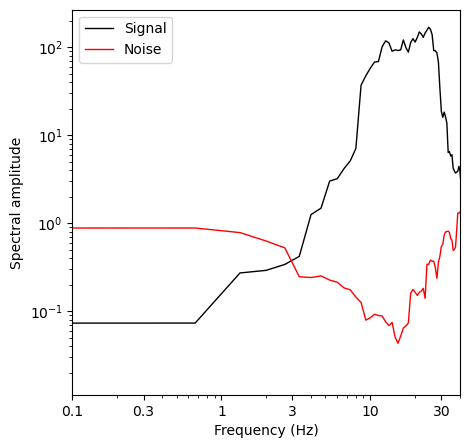

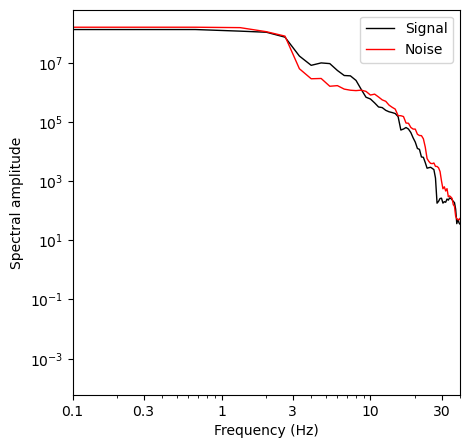

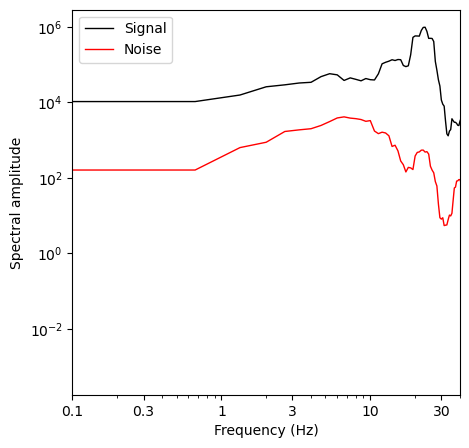

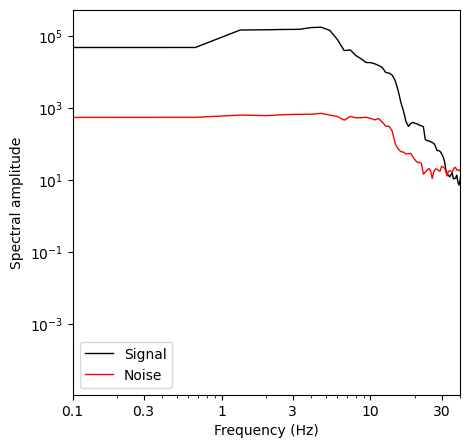

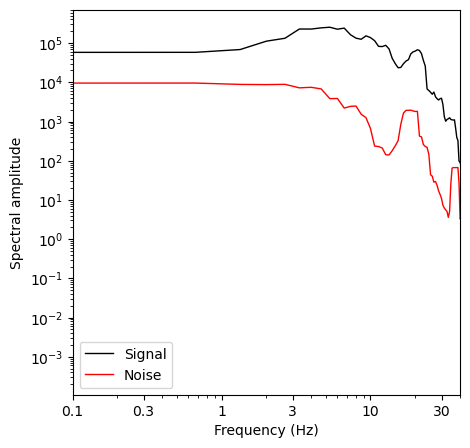

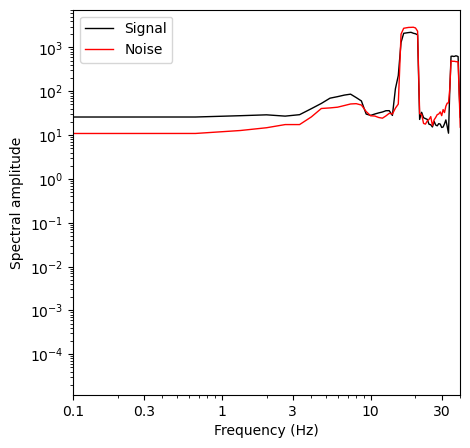

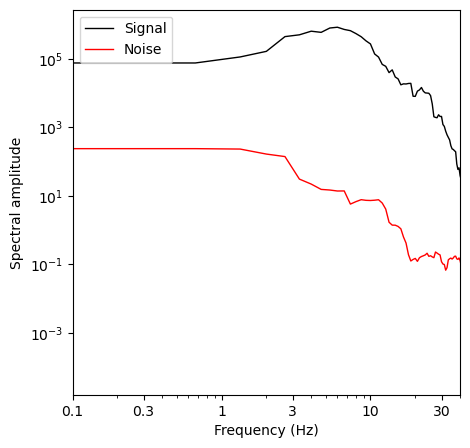

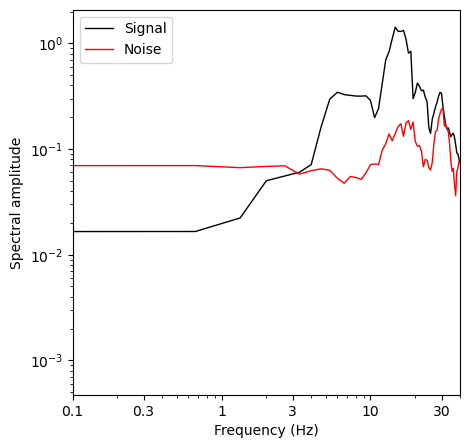

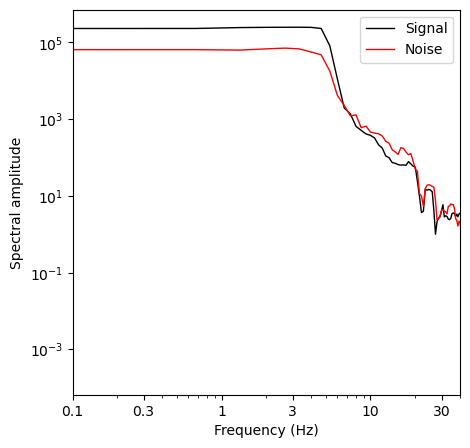

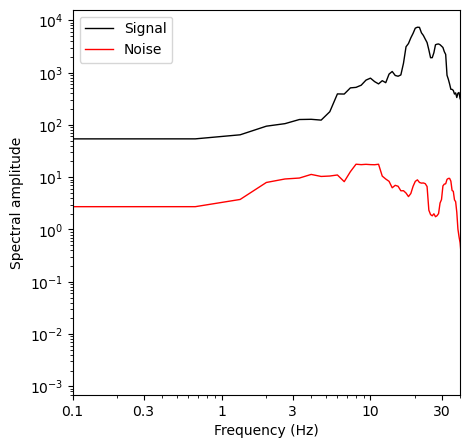

In [516]:
# choose 10 random rows in df, loop over each, make plot of signal spectrum (s2) and noise spectrum (s1)
iplot = np.random.choice(len(df), 10, replace=False)

for i in iplot:
    fig, ax1 = plt.subplots(1,1, figsize=(5,5))
    ax1.loglog(f_resample, df.loc[i, 's2'], c=c_signal, lw=1, label='Signal')
    ax1.loglog(f_resample, df.loc[i, 's1'], c=c_noise, lw=1, label='Noise')
    ax1.set_xlim([0.1, 40])
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('Spectral amplitude')
    ax1.set_xticks([0.1, 0.3, 1, 3, 10, 30])
    ax1.set_xticklabels([0.1, 0.3, 1, 3, 10, 30])
    ax1.legend()
    plt.show()